<a href="https://colab.research.google.com/github/mishraaashkacs242511-maker/Aashka/blob/main/T095_Aashka_Mishra_AI_Prac_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Social_Network_Ads.csv to Social_Network_Ads (1).csv


Saving Social_Network_Ads.csv to Social_Network_Ads (3).csv
First 5 rows of the dataset:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Dataset shape:
(400, 5)

Missing values:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Features:
   Age  EstimatedSalary
0   19            19000
1   35            20000
2   26            43000
3   27            57000
4   19            76000

Target:
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

Training samples: 320
Testing samples: 80

K-NN model trained successfully!

Predicted values:
[1 0 0 1 0 1 0 1 1 0 0 1 1 0 1 0 0 1 0 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 1
 1 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 

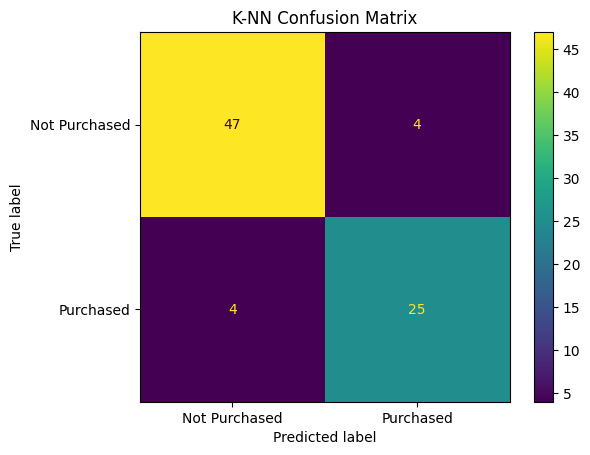


Actual vs Predicted:
   Age  EstimatedSalary  Actual  Predicted
0   48           119000       1          1
1   26            15000       0          0
2   35            20000       0          0
3   38           112000       0          1
4   20            82000       0          0
5   54            70000       1          1
6   40            75000       0          0
7   60           102000       1          1
8   59            83000       0          1
9   36            33000       0          0


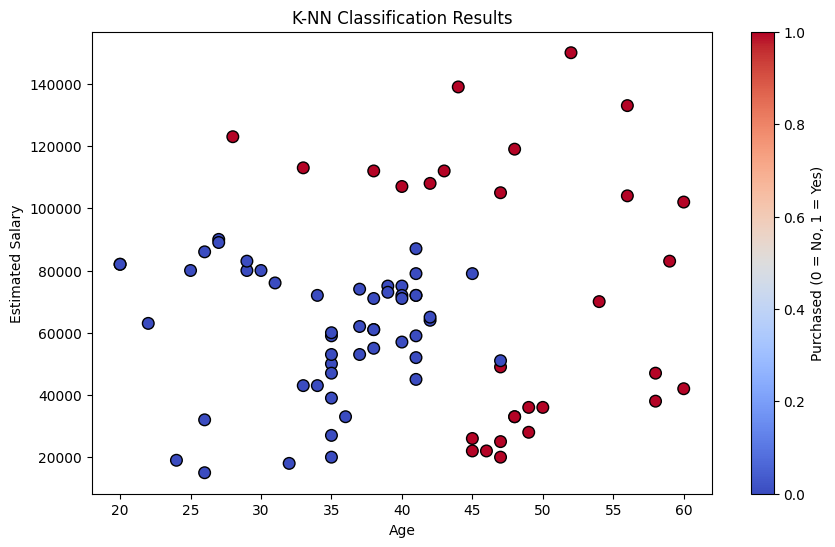

NEW USER PREDICTION
Prediction: User is NOT likely to purchase


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

uploaded = files.upload()

df = pd.read_csv("Social_Network_Ads.csv")

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

print("\nK-NN model trained successfully!")

y_pred = knn.predict(X_test_scaled)

print("\nPredicted values:")
print(y_pred)

accuracy = accuracy_score(y_test, y_pred)

print("K-NN CLASSIFICATION RESULTS")

print("Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Purchased", "Purchased"]
))

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Purchased", "Purchased"]
)

disp.plot()
plt.title("K-NN Confusion Matrix")
plt.show()

results = pd.DataFrame({
    'Age': X_test['Age'].values,
    'EstimatedSalary': X_test['EstimatedSalary'].values,
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("\nActual vs Predicted:")
print(results.head(10))

plt.figure(figsize=(10, 6))

plt.scatter(
    X_test['Age'],
    X_test['EstimatedSalary'],
    c=y_pred,
    cmap='coolwarm',
    edgecolor='black',
    s=70
)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("K-NN Classification Results")
plt.colorbar(label="Purchased (0 = No, 1 = Yes)")

plt.show()

new_user = [[35, 70000]]

new_user_scaled = scaler.transform(new_user)

prediction = knn.predict(new_user_scaled)

print("NEW USER PREDICTION")

if prediction[0] == 1:
    print("Prediction: User is likely to PURCHASE")
else:
    print("Prediction: User is NOT likely to purchase")